In [61]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [62]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [63]:
myPredictorsDf = pd.read_csv('eICUPredictors.csv')

/tmp/ipykernel_442157/3681958123.py:1: DtypeWarning: Columns (14,16,41,66,76,89,114,124) have mixed types. Specify dtype option on import or set low_memory=False.
  myPredictorsDf = pd.read_csv('eICUPredictors.csv')


In [64]:
print(list(myPredictorsDf.columns))

['patientunitstayid', 'gender', 'age', 'apacheadmissiondx', 'admissionheight', 'hospitaladmittime24', 'hospitaladmitsource', 'admissionweight', 'PEA', 'Asystole', 'VTachy', 'VFib', 'Hypothermia', 'FirstGCSTime', 'FirstGCS', 'LastGCSTime', 'LastGCS', 'FirstMGCSTime', 'FirstMGCS', 'LastMGCSTime', 'LastMGCS', 'Lactate', 'Troponin', 'Chloride', 'hospitaldischargestatus', 'DeathAtDischarge', 'LastGCS15', 'IAP', 'pH.1', 'Respiratory Rate.1', 'Tobramycin - trough', 'Gentamicin - trough', 'cd 4', 'Gentamicin - random', 'Gentamicin - peak', 'NAPA', 'Procainamide', 'Amikacin - trough', 'Tobramycin - peak', 'Amikacin - peak', 'Vancomycin - peak', 'firstGCS Total', 'firstHeart Rate', 'firstNon-Invasive BP Diastolic', 'firstNon-Invasive BP Mean', 'firstNon-Invasive BP Systolic', 'firstO2 Saturation', 'firstRespiratory Rate', 'firstTemperature (C)', 'firstTemperature (F)', 'firstTemperature Location', 'firstValue', 'firstInvasive BP Diastolic', 'firstInvasive BP Systolic', 'firstPain Score', 'firstC

In [65]:
myPredictorsDf.select_dtypes(include=['object']).columns

Index(['gender', 'apacheadmissiondx', 'hospitaladmittime24',
       'hospitaladmitsource', 'FirstGCS', 'LastGCS', 'hospitaldischargestatus',
       'firstGCS Total', 'firstTemperature Location', 'firstValue',
       'firstSedation Scale', 'firstDelirium Scale', 'firstDelirium Score',
       'firstElectrolyte Replacement', 'firstFall Risk', 'lastGCS Total',
       'lastTemperature Location', 'lastValue', 'lastSedation Scale',
       'lastDelirium Scale', 'lastDelirium Score',
       'lastElectrolyte Replacement', 'lastFall Risk'],
      dtype='object')

In [70]:
# myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int
myFilter = (myPredictorsDf['FirstGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['FirstGCS'].isna()) & (myPredictorsDf['LastGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastGCS'].isna())
myFilter = myFilter & (myPredictorsDf['FirstMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['FirstMGCS'].isna()) & (myPredictorsDf['LastMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastMGCS'].isna())
myFilter = myFilter & (myPredictorsDf['FirstMGCSTime'] != myPredictorsDf['LastMGCSTime']) & (myPredictorsDf['FirstGCSTime'] != myPredictorsDf['LastGCSTime'])
myPredictorsDf.loc[myPredictorsDf['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
myPredictorsDf.gender = (myPredictorsDf.gender == 'Male').astype(int)
myPredictorsDf.LastGCS15 = 0
myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int)
myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastMGCS'].astype(int) == 6).astype(int)

In [71]:
myPredictorsDf.columns

Index(['patientunitstayid', 'gender', 'age', 'apacheadmissiondx',
       'admissionheight', 'hospitaladmittime24', 'hospitaladmitsource',
       'admissionweight', 'PEA', 'Asystole',
       ...
       'minSVRI', 'meanSVRI', 'maxPAOP', 'minPAOP', 'meanPAOP', 'maxPVRI',
       'minPVRI', 'meanPVRI', 'LastGCSPositive', 'LastMGCSPositive'],
      dtype='object', length=968)

In [72]:
myXValue = myPredictorsDf.drop(columns= ['GCS Total', 'LastMGCSTime', 'FirstMGCSTime', 'Motor', 'LastMGCSPositive', 'LastMGCS', 'Sedation Scale', 'Electrolyte Replacement', 'Fall Risk', 'O2 Admin Device', 'Temperature Location', 'Value', 'Delirium Scale', 'Delirium Score', 'LastGCSPositive', 'apacheadmissiondx', 'hospitaladmittime24', 'FirstGCSTime', 'LastGCSTime', 'LastGCS', 'hospitaldischargestatus', 'LastGCS15', 'hospitaladmitsource', 'DeathAtDischarge', 'patientunitstayid'])
myXValue = myXValue[myFilter]
myXValue.FirstGCS = myXValue.FirstGCS.astype(int)
myYValue = myPredictorsDf[myFilter]['LastMGCSPositive']
myYValue = myYValue.astype(int)

X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[myFilter][['LastGCS15', 'Hypothermia']], test_size=0.3)

KeyError: "['GCS Total', 'Motor', 'Sedation Scale', 'Electrolyte Replacement', 'Fall Risk', 'O2 Admin Device', 'Temperature Location', 'Value', 'Delirium Scale', 'Delirium Score'] not found in axis"

In [ ]:
myGridSearchCv = gridSearchKFoldClassification(X_train=X_train_transf[selected_features], X_test = X_test_transf[selected_features], y_train = y_train, y_test=y_test, aScore='roc_auc', aGrid = DefaultGrid)
myBestModel = myGridSearchCv.best_estimator_

In [ ]:
# from sklearn.feature_selection import RFECV
# from scikeras.wrappers import KerasClassifier
# from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# # Assuming you have a function to build your Keras model
# def build_model():
#     model = Sequential()
#     model.add(Dense(64, activation='relu', input_shape=(X_train_transf.shape[1],)))
#     model.add(Dense(32, activation='relu'))
#     model.add(Dense(1, activation='sigmoid'))  # For binary classification
#     model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#     return model

# # Wrap the model with KerasClassifier
# model_wrapper = KerasClassifier(model=build_model, epochs=10, batch_size=32, verbose=0)
# selector = RFECV(model_wrapper, step=20, cv=3, scoring='roc_auc', n_jobs=-1)
# myPipelineSteps = getDefaultPipelineSteps(X_train)
# myPipeline = Pipeline(myPipelineSteps)
# X_train_transf = myPipeline.fit_transform(X_train)
# X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
# X_train_reduced = selector.fit_transform(X_train_transf, y_train)

In [45]:
selected_features = X_train_transf.columns[selector.support_]
X_train_transf[selected_features]

,num__Lactate,num__Respiratory Rate,num__CI,num__Sedation Score,num__End Tidal CO2,num__CO,num__PA Mean,num__PA Diastolic,num__PA Systolic,num__MCH,...,remainder__ethanol_nan,remainder__Tobramycin - trough_nan,remainder__Gentamicin - trough_1.4,remainder__Gentamicin - random_nan,remainder__Device_840.0,remainder__Device_nan,remainder__Spontaneous Rate_nan,remainder__Gentamicin - peak_nan,remainder__Tobramycin - peak_nan,remainder__PTT ratio_6.6
0,9.542448e-01,8.859355e-17,-2.921640e-18,-2.018587e-17,5.669224e-17,1.387779e-16,1.082467e-16,7.822026e-17,-2.498002e-16,8.417924e-16,...,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
1,1.690513e-02,8.859355e-17,-2.921640e-18,1.078786e+00,5.669224e-17,1.387779e-16,1.082467e-16,7.822026e-17,-2.498002e-16,8.417924e-16,...,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
2,-1.011882e+00,8.859355e-17,-2.921640e-18,-2.018587e-17,5.669224e-17,1.387779e-16,1.082467e-16,7.822026e-17,-2.498002e-16,8.417924e-16,...,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
3,-8.061248e-01,8.859355e-17,-2.921640e-18,-2.018587e-17,5.669224e-17,1.387779e-16,1.082467e-16,7.822026e-17,-2.498002e-16,2.947098e-01,...,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
4,1.274312e+00,8.859355e-17,-2.921640e-18,-2.018587e-17,5.669224e-17,1.387779e-16,1.082467e-16,7.822026e-17,-2.498002e-16,9.948637e-01,...,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1741,-6.689531e-01,8.859355e-17,-2.921640e-18,1.472421e+00,5.669224e-17,1.387779e-16,1.082467e-16,7.822026e-17,-2.498002e-16,-1.289849e+00,...,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
1742,-5.089196e-01,8.859355e-17,-2.921640e-18,-4.957529e-01,-6.440420e-01,1.387779e-16,1.082467e-16,7.822026e-17,-2.498002e-16,8.417924e-16,...,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
1743,7.016051e-17,8.859355e-17,-2.921640e-18,-2.018587e-17,5.669224e-17,1.387779e-16,1.082467e-16,7.822026e-17,-2.498002e-16,8.417924e-16,...,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
1744,9.771067e-01,1.207317e+00,-2.921640e-18,-2.018587e-17,5.669224e-17,1.387779e-16,1.082467e-16,7.822026e-17,-2.498002e-16,8.417924e-16,...,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0


In [46]:
selected_features

Index(['num__Lactate', 'num__Respiratory Rate', 'num__CI',
       'num__Sedation Score', 'num__End Tidal CO2', 'num__CO', 'num__PA Mean',
       'num__PA Diastolic', 'num__PA Systolic', 'num__MCH', 'num__MCHC',
       'num__MCV', 'num__amylase', 'num__LDL', 'num__TSH', 'num__ammonia',
       'num__prealbumin', 'num__myoglobin', 'num__free T4',
       'num__Respiratory Rate.1', 'bin__VTachy', 'bin__VFib', 'bin__prolactin',
       'bin__T4', 'bin__Tacrolimus-FK506', 'remainder__FirstMGCS_1.0',
       'remainder__FirstMGCS_2.0', 'remainder__FirstMGCS_3.0',
       'remainder__FirstMGCS_5.0', 'remainder__FirstMGCS_6.0',
       'remainder__Pain Score_0.0', 'remainder__Pain Score_3.0',
       'remainder__Pain Score_4.0', 'remainder__Pain Score_5.0',
       'remainder__Pain Score_8.0', 'remainder__Pain Score_nan',
       'remainder__Eyes_2.0', 'remainder__Eyes_3.0', 'remainder__Eyes_nan',
       'remainder__Verbal_2.0', 'remainder__Verbal_3.0',
       'remainder__Verbal_5.0', 'remainder__Verba

In [39]:
X_test_transf = myPipeline.transform(X_test)
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())
X_test_transf

,num__age,num__admissionheight,num__admissionweight,num__FirstGCS,num__Lactate,num__Troponin,num__pH,num__Chloride,num__Heart Rate,num__Non-Invasive BP Diastolic,...,remainder__Site_nan,remainder__Amikacin - peak_nan,remainder__PTT ratio_1.0,remainder__PTT ratio_1.5,remainder__PTT ratio_2.6,remainder__PTT ratio_3.7,remainder__PTT ratio_6.6,remainder__PTT ratio_nan,remainder__Vancomycin - peak_10.3,remainder__Vancomycin - peak_nan
0,-0.209476,-1.113793,-0.088754,-0.166378,-5.089196e-01,-1.823333e-01,-2.185478e-15,0.086105,0.518847,1.391379,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,-0.145579,1.016016,1.376529,-0.913797,-3.260240e-01,-1.647982e-01,-2.185478e-15,0.645182,0.518847,0.177465,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.237801,0.818248,-0.188408,-0.166378,-6.232293e-01,-5.791800e-02,4.262507e-01,0.225874,-0.373884,2.200655,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,-0.592856,-0.497670,-0.531660,-0.913797,6.341776e-01,-1.759872e-01,-7.919375e-01,1.204260,0.858935,-0.496932,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,1.260149,1.016016,1.417128,-0.664657,7.016051e-17,-1.840033e-01,4.262507e-01,-0.333203,-1.861769,-0.272133,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
744,-0.528959,0.240157,-0.206862,-0.166378,7.016051e-17,-1.831683e-01,-2.185478e-15,-0.053664,0.178759,1.391379,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
745,-1.615204,1.023622,0.778605,-0.913797,-9.661584e-01,-1.647982e-01,-2.185478e-15,1.483799,0.646380,-0.272133,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
746,-0.209476,0.240157,1.454037,-0.913797,-5.956816e-03,4.450674e-18,1.142832e+00,0.505413,2.814441,0.312344,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
747,0.237801,-2.095026,-0.479988,1.079319,7.484873e-01,-1.814983e-01,-5.769631e-01,-0.053664,-1.309126,-0.766690,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


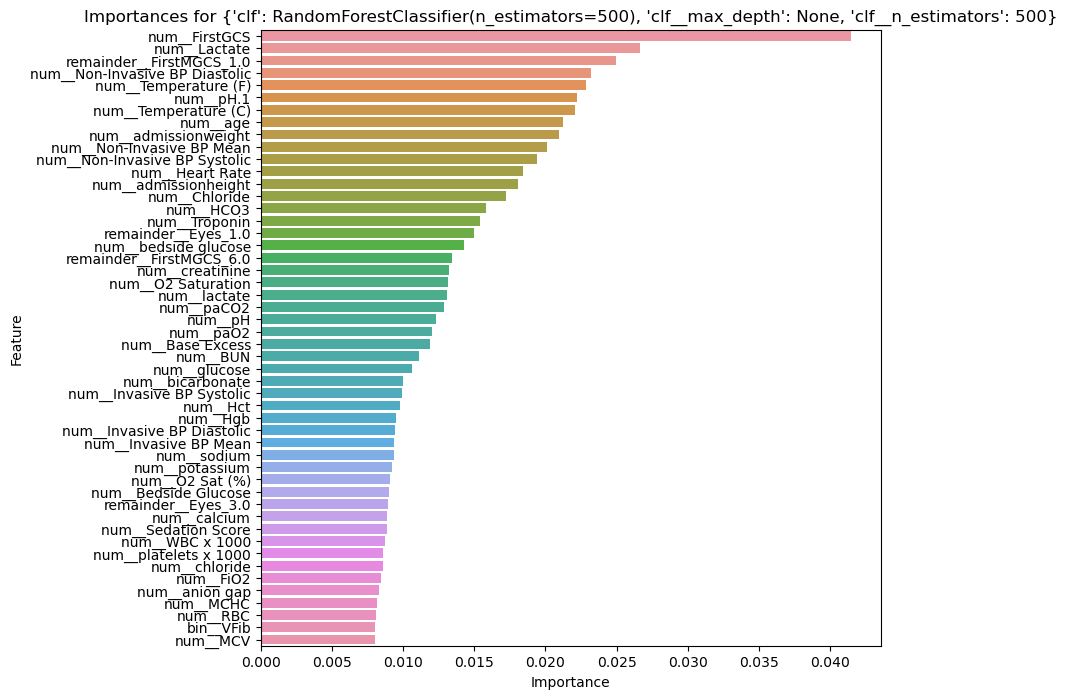

In [50]:

myFeatureImportancesDf = getTopFeatures(myGridSearchCv, list(myBestModel.named_steps.preprocessor.get_feature_names_out()), X_train, y_train)

In [69]:
from scikeras.wrappers import KerasClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# Assuming you have a function to build your Keras model
def build_model():
    model = keras.Sequential()
    model.add(layers.Dense(64, activation='relu', input_shape=(X_train_transf.shape[1],)))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))  # For binary classification
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Wrap the model with KerasClassifier
model_wrapper = KerasClassifier(model=build_model, epochs=10, batch_size=32, verbose=1)
DefaultGrid = [
    {
        'clf': [XGBClassifier(eval_metric='logloss'), RandomForestClassifier()],
        'clf__n_estimators': [5, 10, 50, 200, 500], 
        'clf__max_depth': [2, 5, 10, 25, None]
    },
    {
        'clf': [DecisionTreeClassifier()],
        'clf__max_depth': [2, 5, 20, 50, None],
        'clf__class_weight': [None, 'balanced']
    },
    {
        'clf': [LogisticRegression(), SVC(probability=True, kernel='linear')],
        'clf__C': [0.1, 1, 10]
    }
    # {
    #     'clf': [KerasClassifier(model=build_model, epochs=30, batch_size=32, verbose=1)]
    # }
]
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    return [('preprocessor', myPreprocessor), ('imputer', KNNImputer(n_neighbors=10))]#, ( ('sfs', SFS(LogisticRegression(), 
         #  k_features='best', 
         #  forward=True, 
         #  floating=False, 
         #  scoring='roc_auc', 
         #  cv=3,
         # verbose=1,
         # n_jobs=-1))]
def getPredictedTreatmentEffectSupervisedClassif(X_train, aModel, aCategory, aGroup):
    myXValueModified1 = X_train.copy()
    myXValueModified1[aGroup] = 1.0
    myXValueModified2 = X_train.copy()
    myXValueModified2[aGroup] = 0.0
    if hasattr(aModel, 'predict_proba'):
        y_pred_proba1 = aModel.predict_proba(myXValueModified1)[:, 1]
        y_pred_proba2 = aModel.predict_proba(myXValueModified2)[:, 1]
    else:
        y_pred_proba1 = aModel.predict(myXValueModified1)
        y_pred_proba2 = aModel.predict(myXValueModified2)
    myNewDf = pd.DataFrame()
    myNewDf['predicted_effect'] = (y_pred_proba1 - y_pred_proba2)
    return plotPredictedTreatmentEffect(myNewDf=myNewDf, aCategory=aCategory)
def getTreatmentEffectDiff(X_train, y_train, aModel, aCategory = 'CPC12', aGroup = 'groupe'):
    lower_third, upper_third, myNewDf = getPredictedTreatmentEffectSupervisedClassif(X_train, aModel, aCategory, aGroup)
    print(lower_third)
    print(upper_third)
    if upper_third == lower_third:
        print(f'No effect difference')
        return 1
    myData = pd.concat([X_train[aGroup], myNewDf['predicted_effect_group'], y_train], axis=1)
    model1 = smf.logit(
        f'{aCategory} ~ predicted_effect_group + {aGroup}',
        data=myData
    ).fit()

    model2 = smf.logit(
        f'{aCategory} ~ predicted_effect_group * {aGroup}',
        data=myData
    ).fit()

    llr = -2*(model1.llf - model2.llf)
    df_diff = model2.df_model - model1.df_model
    p_value = chi2.sf(llr, df_diff)

    print(f'Likelihood ratio of test results:')
    print(f'Chi square statistic: {llr}')
    print(f'p-value: {p_value}')
    print(f'Degress of freedom: {df_diff}')
    print(f'NonInteraction p-value: {model1.summary()}')
    print(f'Interaction p-value: {model2.summary()}')
    return p_value

-0.014000000000000012
0.008


PatsyError: Error evaluating factor: NameError: name 'DeathAtDischarge' is not defined
    DeathAtDischarge ~ predicted_effect_group + Hypothermia
    ^^^^^^^^^^^^^^^^

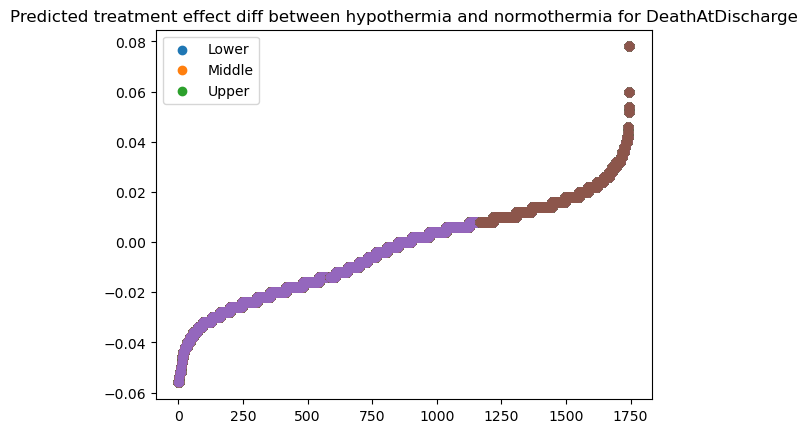

In [51]:
# getTreatmentEffectDiff(myXValue, myYValue, myBestModel, 'LastGCS15', 'Hypothermia')
# myNewDf = pd.DataFrame()
# myNewDf['predicted_effect_group'] = myBestModel.predict(X_test)
getTreatmentEffectDiff(X_train, y_train, myBestModel, 'DeathAtDischarge', 'Hypothermia')

-0.006000000000000005
0.001999999999999974
Optimization terminated successfully.
         Current function value: 0.654791
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.654027
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 1.0572722026490737
p-value: 0.589408314933102
Degress of freedom: 2.0
NonInteraction p-value:                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                  692
Model:                          Logit   Df Residuals:                      688
Method:                           MLE   Df Model:                            3
Date:                Sun, 02 Feb 2025   Pseudo R-squ.:                 0.01808
Time:                        19:09:05   Log-Likelihood:                -453.12
converged:                       True   LL-Null:                       -461.46
Covariance Type:            nonrobust   LLR p-valu

0.589408314933102

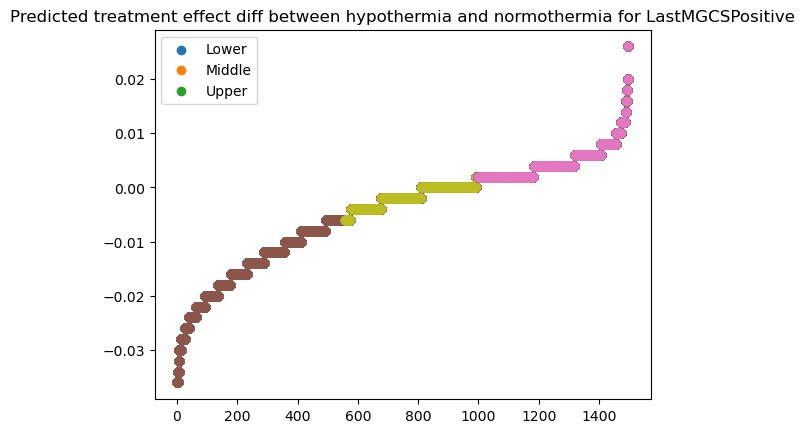

In [29]:
getTreatmentEffectDiff(X_train, y_train, myBestModel, 'LastMGCSPositive', 'Hypothermia')